<a href="https://colab.research.google.com/github/Mrudula7-P/Stock-Market-Sentiment-Price-Movement-Predictor/blob/main/Stock_Market_Sentiment_Price_Movement_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
import joblib

In [3]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [4]:
file_path = "/content/stocks.csv"
df = pd.read_csv(file_path)

print("Dataset Preview:")
print(df.head())


Dataset Preview:
    mic symbol          isin        date  open_value  high_value  low_value  \
0  XZAG    CBX  HRZB00ICBEX6  2015-12-30     1689.22     1689.71    1673.62   
1  XZAG    CBX  HRZB00ICBEX6  2015-12-29     1675.79     1691.02    1673.37   
2  XZAG    CBX  HRZB00ICBEX6  2015-12-28     1655.92     1677.17    1652.76   
3  XZAG    CBX  HRZB00ICBEX6  2015-12-23     1647.66     1655.77    1641.41   
4  XZAG    CBX  HRZB00ICBEX6  2015-12-22     1655.71     1655.71    1642.60   

   last_value  change_prev_close_percentage    turnover  
0     1689.63                         -0.02  2017520.82  
1     1689.94                          0.84  1094356.06  
2     1675.88                          1.21  1125687.29  
3     1655.77                          0.49   592284.75  
4     1647.67                         -0.55  2714509.05  


In [5]:
# Convert date
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

In [6]:
# Fill missing values
df.ffill(inplace=True)

In [7]:
# Sentiment Analysis
if 'Headline' in df.columns:
    sid = SentimentIntensityAnalyzer()
    df['Sentiment'] = df['Headline'].apply(
        lambda x: sid.polarity_scores(str(x))['compound']
    )
else:
    df['Sentiment'] = 0

In [8]:
# Rename columns if needed
df.rename(columns={
    'open_value': 'Open',
    'high_value': 'High',
    'low_value': 'Low',
    'last_value': 'Close',
    'turnover': 'Volume'
}, inplace=True)

In [9]:
df.columns

Index(['mic', 'symbol', 'isin', 'date', 'Open', 'High', 'Low', 'Close',
       'change_prev_close_percentage', 'Volume', 'Sentiment'],
      dtype='object')

In [11]:
# Technical Indicators
df['SMA_5'] = df['Close'].rolling(window=5).mean()
df['SMA_10'] = df['Close'].rolling(window=10).mean()
df['Volatility'] = df['Close'].rolling(window=5).std()

In [12]:
# Price change
df['Price_Change'] = df['Close'].pct_change()

In [13]:
# Target variable (Next day movement)
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

df.dropna(inplace=True)

In [14]:
# Features
features = [
    'Open','High','Low','Close',
    'Volume','Sentiment',
    'SMA_5','SMA_10',
    'Volatility','Price_Change'
]

In [15]:
X = df[features]
y = df['Target']

In [33]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)

In [34]:
# Model
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

In [35]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, n_estimators=300, random_state=42)

In [36]:
# Prediction
y_pred = model.predict(X_test)

In [37]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6845637583892618

Classification Report

              precision    recall  f1-score   support

           0       0.67      0.77      0.72       154
           1       0.70      0.60      0.65       144

    accuracy                           0.68       298
   macro avg       0.69      0.68      0.68       298
weighted avg       0.69      0.68      0.68       298



In [38]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

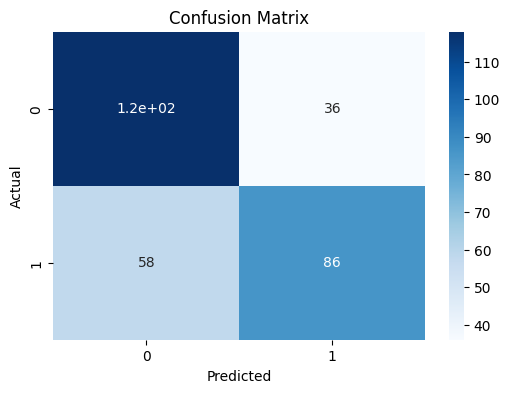

In [39]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance\n")
print(importance)


Feature Importance

        Feature  Importance
0          Open    0.218227
3         Close    0.162639
6         SMA_5    0.104398
1          High    0.094589
2           Low    0.093874
4        Volume    0.093321
7        SMA_10    0.080626
8    Volatility    0.077183
9  Price_Change    0.075143
5     Sentiment    0.000000


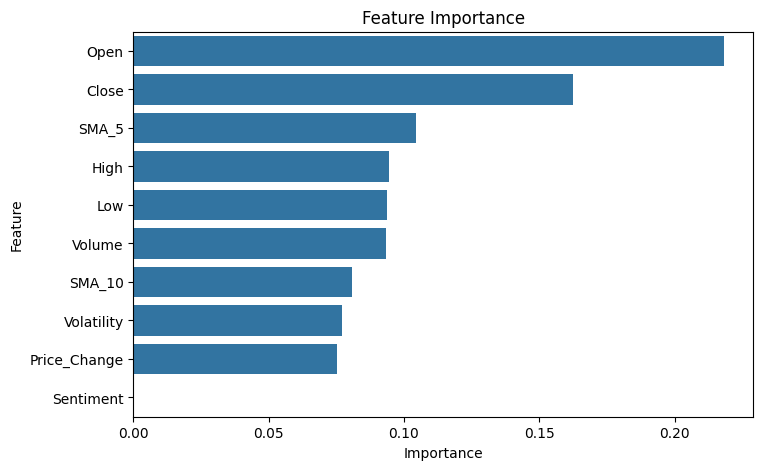

In [41]:
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()

In [42]:
# Cross Validation
scores = cross_val_score(model, X, y, cv=5)
print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.7172214313153911


In [43]:
# Save Model
joblib.dump(model, "stock_price_predictor.pkl")

['stock_price_predictor.pkl']